# Car Price Prediction Using Machine Learning

## 1. Introduction

This project focuses on predicting used car prices using machine learning.

The analysis includes data cleaning, exploratory data analysis, feature engineering, categorical encoding, model training, evaluation, and comparison of regression models.

The objective is to understand which vehicle characteristics are associated with car prices and build a model capable of predicting the price of a used car.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

In [2]:
import os

files = os.listdir()

print("Files in project folder:")
for file in files:
    print(file)

Files in project folder:
Task3_Car_Price_Prediction.ipynb
Used_Car_Price_Prediction.csv


In [3]:
df = pd.read_csv("Used_Car_Price_Prediction.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (7400, 29)


In [4]:
df.head()

,car_name,yr_mfr,fuel_type,kms_run,sale_price,city,times_viewed,body_type,transmission,variant,...,total_owners,broker_quote,original_price,car_rating,ad_created_on,fitness_certificate,emi_starts_from,booking_down_pymnt,reserved,warranty_avail
0,maruti swift,2015,petrol,8063,386399,noida,18715,hatchback,manual,lxi opt,...,2,397677,404177.0,great,2021-04-04T07:09:18.583,True,8975,57960,False,False
1,maruti alto 800,2016,petrol,23104,265499,noida,2676,hatchback,manual,lxi,...,1,272935,354313.0,great,2021-03-22T14:07:32.833,True,6167,39825,False,False
2,hyundai grand i10,2017,petrol,23402,477699,noida,609,hatchback,manual,sports 1.2 vtvt,...,1,469605,NaN,great,2021-03-20T05:36:31.311,True,11096,71655,False,False
3,maruti swift,2013,diesel,39124,307999,noida,6511,hatchback,manual,vdi,...,1,294262,374326.0,great,2021-01-21T12:59:19.299,True,7154,46200,False,False
4,hyundai grand i10,2015,petrol,22116,361499,noida,3225,hatchback,manual,magna 1.2 vtvt,...,1,360716,367216.0,great,2021-04-01T13:33:40.733,True,8397,54225,False,False


In [5]:
df.tail()

,car_name,yr_mfr,fuel_type,kms_run,sale_price,city,times_viewed,body_type,transmission,variant,...,total_owners,broker_quote,original_price,car_rating,ad_created_on,fitness_certificate,emi_starts_from,booking_down_pymnt,reserved,warranty_avail
7395,honda amaze,2018,diesel,53486,604299,ghaziabad,2756,sedan,NaN,1.5 v cvt i-dtec,...,1,630810,787750.0,great,2021-02-07T08:05:30.443,True,14036,90645,True,False
7396,maruti ignis,2018,petrol,8854,562599,chennai,640,hatchback,manual,delta 1.2 k12,...,1,549440,NaN,great,2021-03-31T10:21:56.289,True,13068,84390,False,False
7397,honda amaze,2015,petrol,46300,400499,pune,795,sedan,manual,1.2 smt i vtec,...,1,383419,NaN,great,2021-03-04T12:40:38.652,True,9303,60075,True,False
7398,maruti alto k10,2016,petrol,27245,284099,new delhi,1155,hatchback,manual,lxi,...,1,286515,369885.0,great,2021-03-16T13:31:39.766,True,6599,42615,False,False
7399,mahindra thar,2017,diesel,37134,671399,new delhi,4603,suv,manual,crde 4x4 bs iv,...,1,646565,NaN,great,2021-03-07T10:10:19.937,True,15595,100710,True,False


In [6]:
print("Number of columns:", len(df.columns))

print("\nColumn names:")
for column in df.columns:
    print(column)

Number of columns: 29

Column names:
car_name
yr_mfr
fuel_type
kms_run
sale_price
city
times_viewed
body_type
transmission
variant
assured_buy
registered_city
registered_state
is_hot
rto
source
make
model
car_availability
total_owners
broker_quote
original_price
car_rating
ad_created_on
fitness_certificate
emi_starts_from
booking_down_pymnt
reserved
warranty_avail


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7400 entries, 0 to 7399
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_name             7400 non-null   str    
 1   yr_mfr               7400 non-null   int64  
 2   fuel_type            7400 non-null   str    
 3   kms_run              7400 non-null   int64  
 4   sale_price           7400 non-null   int64  
 5   city                 7400 non-null   str    
 6   times_viewed         7400 non-null   int64  
 7   body_type            7297 non-null   str    
 8   transmission         6844 non-null   str    
 9   variant              7400 non-null   str    
 10  assured_buy          7400 non-null   bool   
 11  registered_city      7390 non-null   str    
 12  registered_state     7390 non-null   str    
 13  is_hot               7400 non-null   bool   
 14  rto                  7400 non-null   str    
 15  source               7274 non-null   str    
 16 

In [8]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

original_price         3280
car_availability        620
transmission            556
source                  126
body_type               103
registered_state         10
registered_city          10
car_rating                9
fitness_certificate       8
ad_created_on             1
dtype: int64

In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1


In [10]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
car_name,7400,185,maruti swift,535,NaN,NaN,NaN,NaN,NaN,NaN,NaN
yr_mfr,7400.0,NaN,NaN,NaN,2013.885676,3.087613,1996.0,2012.0,2014.0,2016.0,2021.0
fuel_type,7400,5,petrol,4659,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kms_run,7400.0,NaN,NaN,NaN,62624.52,43532.042371,60.0,31885.25,55765.0,84184.0,996609.0
sale_price,7400.0,NaN,NaN,NaN,454889.192027,282702.329741,0.0,281174.0,382449.0,540149.0,3866000.0
city,7400,13,mumbai,1336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
times_viewed,7400.0,NaN,NaN,NaN,1550.706081,2080.952842,3.0,554.75,1088.0,1926.5,61930.0
body_type,7297,5,hatchback,4358,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,6844,2,manual,6215,NaN,NaN,NaN,NaN,NaN,NaN,NaN
variant,7400,943,vxi,674,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
numeric_columns = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(list(numeric_columns))

Numerical columns:
['yr_mfr', 'kms_run', 'sale_price', 'times_viewed', 'total_owners', 'broker_quote', 'original_price', 'emi_starts_from', 'booking_down_pymnt']


In [12]:
categorical_columns = df.select_dtypes(include="object").columns

print("Categorical columns:")
print(list(categorical_columns))

Categorical columns:
['car_name', 'fuel_type', 'city', 'body_type', 'transmission', 'variant', 'registered_city', 'registered_state', 'rto', 'source', 'make', 'model', 'car_availability', 'car_rating', 'ad_created_on', 'fitness_certificate']


C:\Users\sanja\AppData\Local\Temp\ipykernel_14212\2798951942.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


In [13]:
for column in categorical_columns:
    print(f"\n{column}")
    print("Unique values:", df[column].nunique())
    print(df[column].dropna().unique()[:15])


car_name
Unique values: 185
<StringArray>
[       'maruti swift',     'maruti alto 800',   'hyundai grand i10',
     'maruti alto k10',         'maruti ritz',         'hyundai i20',
   'hyundai elite i20',        'renault kwid',         'hyundai i10',
          'honda brio',          'honda city',         'hyundai eon',
       'hyundai verna',         'maruti alto', 'hyundai santro xing']
Length: 15, dtype: str

fuel_type
Unique values: 5
<StringArray>
['petrol', 'diesel', 'petrol & cng', 'electric', 'petrol & lpg']
Length: 5, dtype: str

city
Unique values: 13
<StringArray>
[    'noida',   'gurgaon', 'bengaluru', 'new delhi',    'mumbai',      'pune',
 'hyderabad',   'chennai',   'kolkata', 'ahmedabad', 'faridabad', 'ghaziabad',
   'lucknow']
Length: 13, dtype: str

body_type
Unique values: 5
<StringArray>
['hatchback', 'sedan', 'suv', 'luxury sedan', 'luxury suv']
Length: 5, dtype: str

transmission
Unique values: 2
<StringArray>
['manual', 'automatic']
Length: 2, dtype: str

varian

In [14]:
before = df.shape[0]

df = df.drop_duplicates()

after = df.shape[0]

print("Rows before:", before)
print("Rows after :", after)
print("Duplicates removed:", before - after)

Rows before: 7400
Rows after : 7399
Duplicates removed: 1


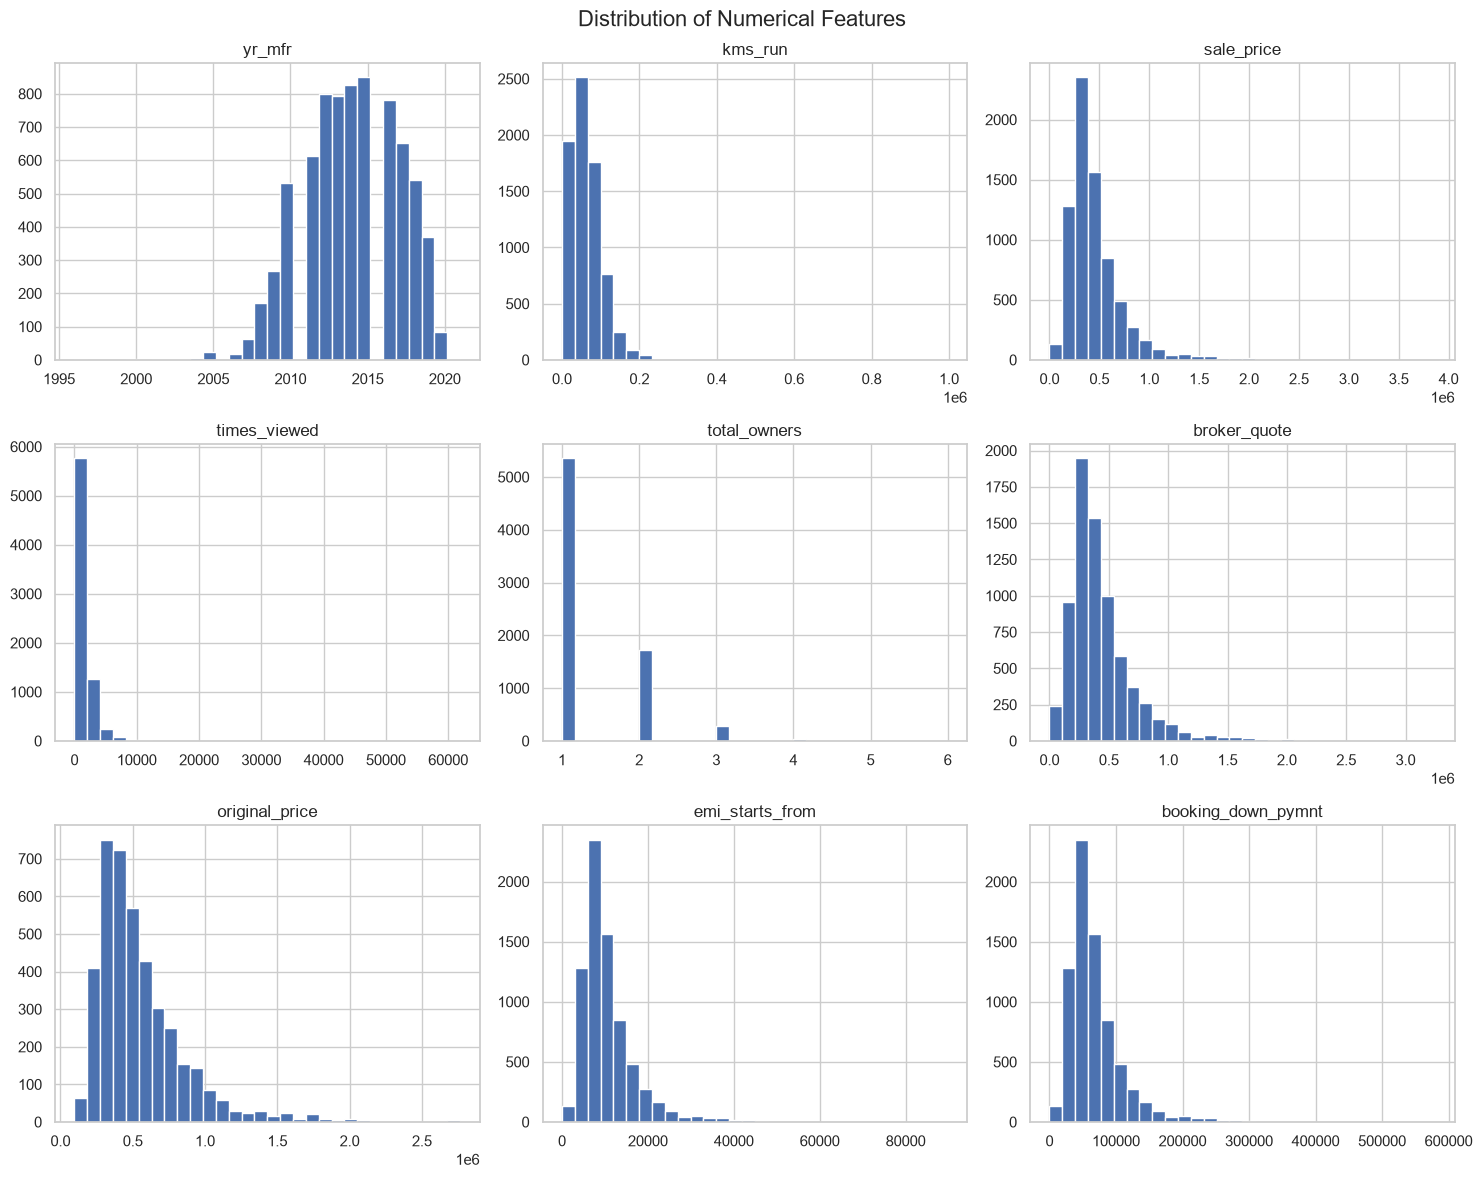

In [15]:
df.hist(
    figsize=(15, 12),
    bins=30
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

In [16]:
print(df.columns.tolist())

['car_name', 'yr_mfr', 'fuel_type', 'kms_run', 'sale_price', 'city', 'times_viewed', 'body_type', 'transmission', 'variant', 'assured_buy', 'registered_city', 'registered_state', 'is_hot', 'rto', 'source', 'make', 'model', 'car_availability', 'total_owners', 'broker_quote', 'original_price', 'car_rating', 'ad_created_on', 'fitness_certificate', 'emi_starts_from', 'booking_down_pymnt', 'reserved', 'warranty_avail']


In [17]:
print(df.columns.tolist())

['car_name', 'yr_mfr', 'fuel_type', 'kms_run', 'sale_price', 'city', 'times_viewed', 'body_type', 'transmission', 'variant', 'assured_buy', 'registered_city', 'registered_state', 'is_hot', 'rto', 'source', 'make', 'model', 'car_availability', 'total_owners', 'broker_quote', 'original_price', 'car_rating', 'ad_created_on', 'fitness_certificate', 'emi_starts_from', 'booking_down_pymnt', 'reserved', 'warranty_avail']


In [18]:
print(df.columns.tolist())

['car_name', 'yr_mfr', 'fuel_type', 'kms_run', 'sale_price', 'city', 'times_viewed', 'body_type', 'transmission', 'variant', 'assured_buy', 'registered_city', 'registered_state', 'is_hot', 'rto', 'source', 'make', 'model', 'car_availability', 'total_owners', 'broker_quote', 'original_price', 'car_rating', 'ad_created_on', 'fitness_certificate', 'emi_starts_from', 'booking_down_pymnt', 'reserved', 'warranty_avail']


In [19]:
for column in df.columns:
    print(f"{column} → {df[column].dtype}")

car_name → str
yr_mfr → int64
fuel_type → str
kms_run → int64
sale_price → int64
city → str
times_viewed → int64
body_type → str
transmission → str
variant → str
assured_buy → bool
registered_city → str
registered_state → str
is_hot → bool
rto → str
source → str
make → str
model → str
car_availability → str
total_owners → int64
broker_quote → int64
original_price → float64
car_rating → str
ad_created_on → str
fitness_certificate → object
emi_starts_from → int64
booking_down_pymnt → int64
reserved → bool
warranty_avail → bool


In [20]:
print("Sale price statistics:")
print(df["sale_price"].describe())

Sale price statistics:
count    7.399000e+03
mean     4.548599e+05
std      2.827102e+05
min      0.000000e+00
25%      2.811490e+05
50%      3.823990e+05
75%      5.400990e+05
max      3.866000e+06
Name: sale_price, dtype: float64


In [21]:
missing = df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

original_price         3279
car_availability        620
transmission            556
source                  126
body_type               103
registered_state         10
registered_city          10
car_rating                9
fitness_certificate       8
ad_created_on             1
dtype: int64

In [22]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [23]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (7399, 29)


In [24]:
CURRENT_YEAR = 2026

df["car_age"] = CURRENT_YEAR - df["yr_mfr"]

df[["yr_mfr", "car_age"]].head()

,yr_mfr,car_age
0,2015,11
1,2016,10
2,2017,9
3,2013,13
4,2015,11


In [25]:
print("Minimum car age:", df["car_age"].min())
print("Maximum car age:", df["car_age"].max())

Minimum car age: 5
Maximum car age: 30


In [26]:
numeric_features = [
    "yr_mfr",
    "kms_run",
    "times_viewed",
    "sale_price",
    "original_price",
    "car_age"
]

df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
yr_mfr,7399.0,2013.885255,3.087609,1996.0,2012.0,2014.0,2016.00,2021.0
kms_run,7399.0,62627.965130,43533.975544,60.0,31881.5,55766.0,84187.00,996609.0
times_viewed,7399.0,1550.293553,2080.790854,3.0,554.5,1088.0,1925.00,61930.0
sale_price,7399.0,454859.929991,282710.227994,0.0,281149.0,382399.0,540099.00,3866000.0
original_price,4120.0,551035.082282,311988.705064,96899.0,341493.0,467480.0,667525.75,2765057.0
car_age,7399.0,12.114745,3.087609,5.0,10.0,12.0,14.00,30.0


## 3. Exploratory Data Analysis

### Sale Price Distribution

Understanding the distribution of sale prices helps identify skewness and possible extreme values before training the regression models.

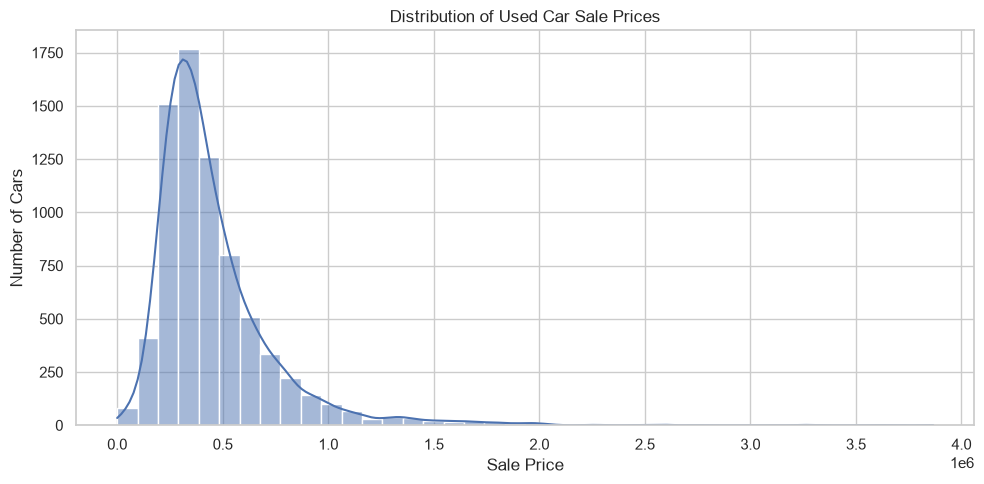

In [27]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["sale_price"],
    bins=40,
    kde=True
)

plt.title("Distribution of Used Car Sale Prices")
plt.xlabel("Sale Price")
plt.ylabel("Number of Cars")

plt.tight_layout()
plt.show()

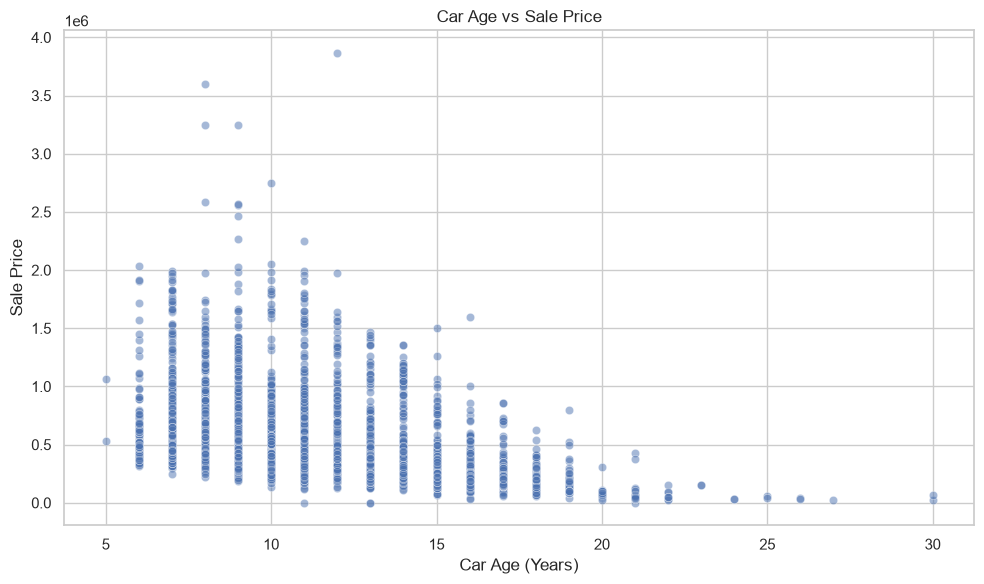

In [28]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="car_age",
    y="sale_price",
    alpha=0.5
)

plt.title("Car Age vs Sale Price")
plt.xlabel("Car Age (Years)")
plt.ylabel("Sale Price")

plt.tight_layout()
plt.show()

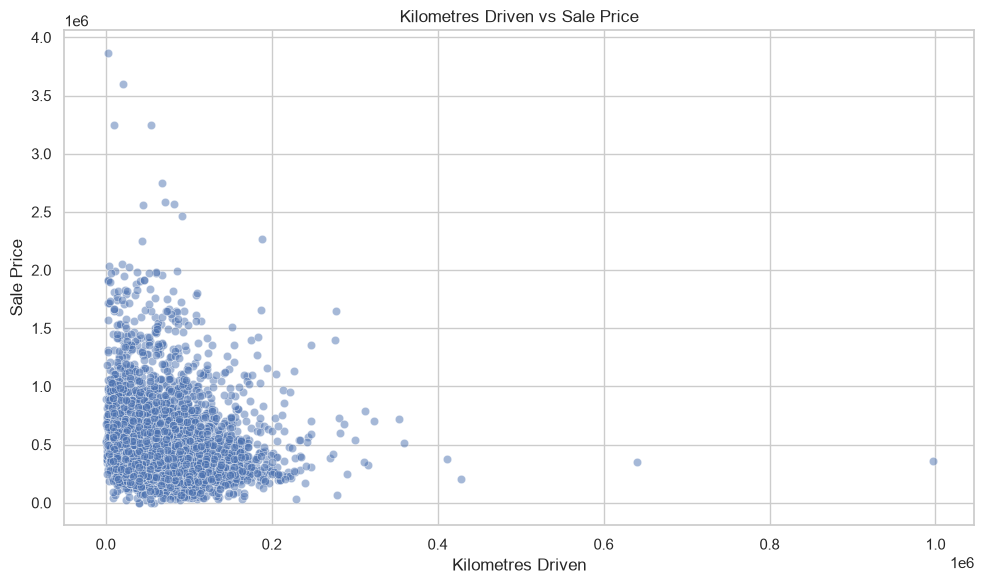

In [29]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="kms_run",
    y="sale_price",
    alpha=0.5
)

plt.title("Kilometres Driven vs Sale Price")
plt.xlabel("Kilometres Driven")
plt.ylabel("Sale Price")

plt.tight_layout()
plt.show()

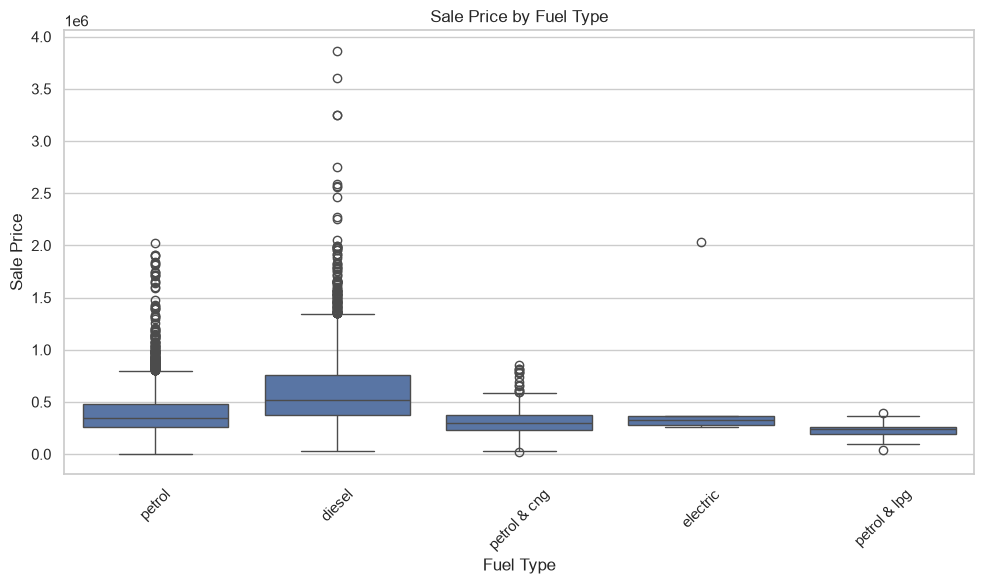

In [30]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="fuel_type",
    y="sale_price"
)

plt.title("Sale Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Sale Price")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

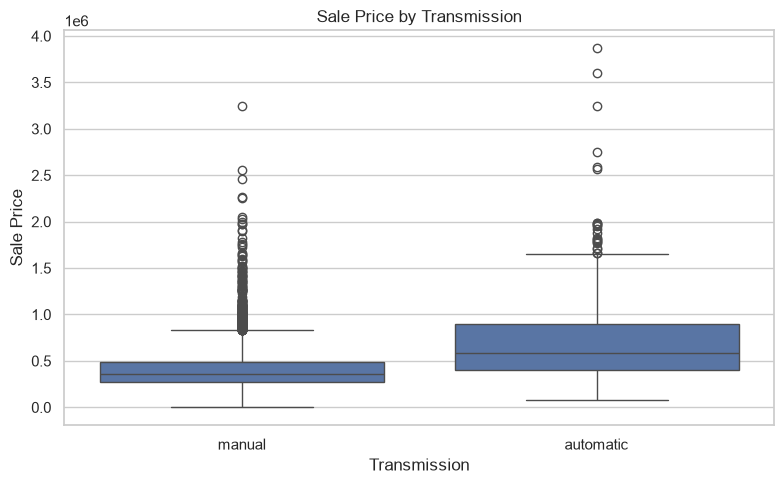

In [31]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="transmission",
    y="sale_price"
)

plt.title("Sale Price by Transmission")
plt.xlabel("Transmission")
plt.ylabel("Sale Price")

plt.tight_layout()
plt.show()

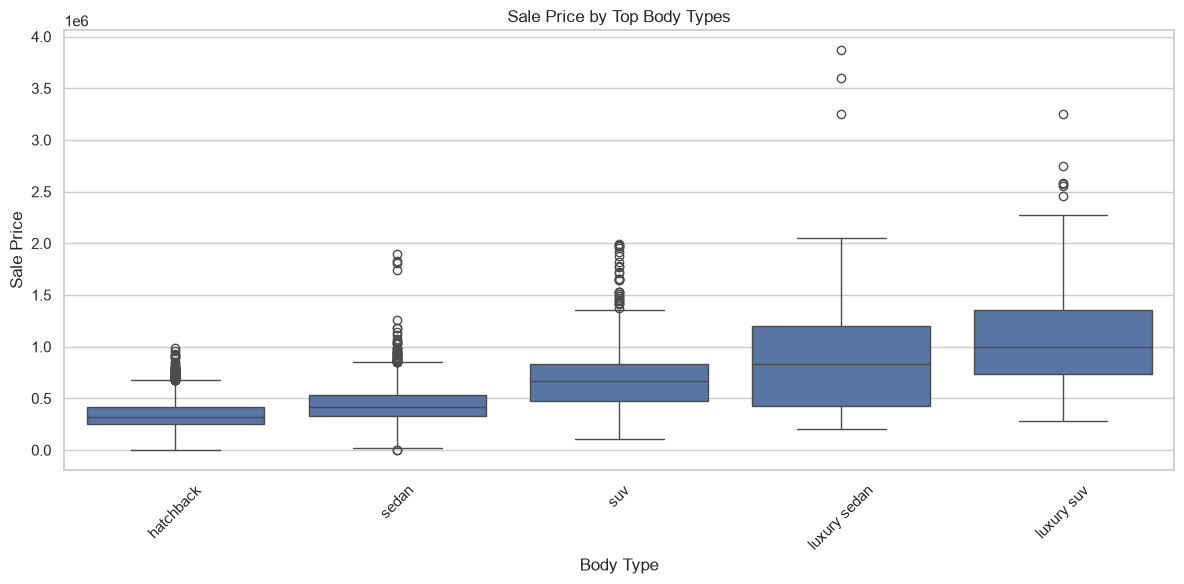

In [32]:
top_body_types = df["body_type"].value_counts().head(10).index

body_df = df[df["body_type"].isin(top_body_types)]

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=body_df,
    x="body_type",
    y="sale_price"
)

plt.title("Sale Price by Top Body Types")
plt.xlabel("Body Type")
plt.ylabel("Sale Price")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [33]:
numeric_corr = df[
    [
        "yr_mfr",
        "kms_run",
        "times_viewed",
        "sale_price",
        "original_price",
        "car_age"
    ]
].corr()

numeric_corr

,yr_mfr,kms_run,times_viewed,sale_price,original_price,car_age
yr_mfr,1.000000,-0.395799,0.059430,0.518925,0.508361,-1.000000
kms_run,-0.395799,1.000000,-0.114698,-0.104673,-0.087615,0.395799
times_viewed,0.059430,-0.114698,1.000000,0.091444,0.103439,-0.059430
sale_price,0.518925,-0.104673,0.091444,1.000000,0.986005,-0.518925
original_price,0.508361,-0.087615,0.103439,0.986005,1.000000,-0.508361
car_age,-1.000000,0.395799,-0.059430,-0.518925,-0.508361,1.000000


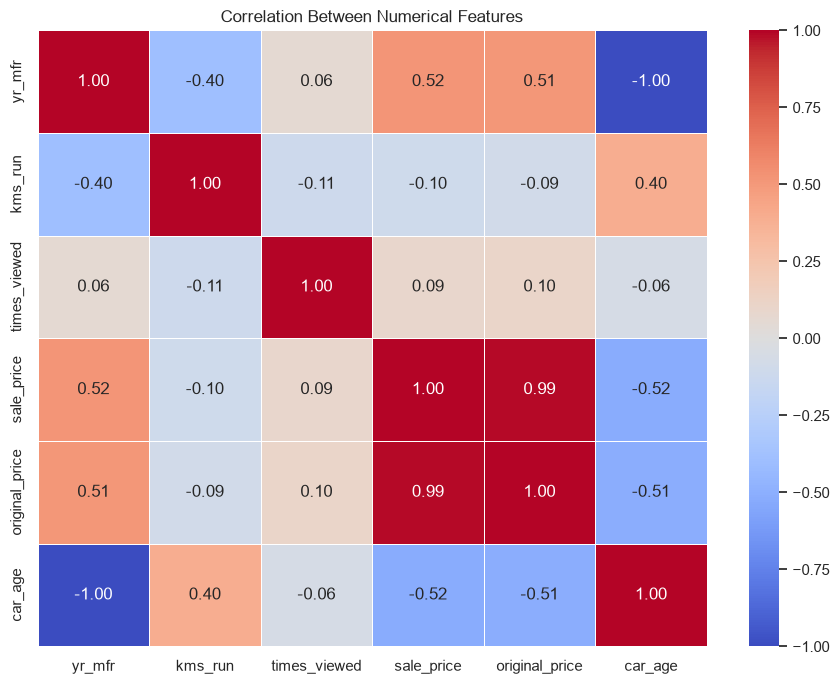

In [34]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    numeric_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Between Numerical Features")

plt.tight_layout()
plt.show()

## 4. Feature Selection

The target variable is `sale_price`.

Features related to the final sale transaction or financing information are excluded to reduce the risk of data leakage.

The selected features describe vehicle characteristics, usage, ownership, location, and listing information.

In [35]:
features = [
    "yr_mfr",
    "car_age",
    "fuel_type",
    "kms_run",
    "city",
    "body_type",
    "transmission",
    "make",
    "model",
    "total_owners",
    "original_price",
    "car_rating",
    "warranty_avail",
    "fitness_certificate"
]

target = "sale_price"

X = df[features]
y = df[target]

print("Features:", features)
print("Target:", target)
print("X shape:", X.shape)
print("y shape:", y.shape)

Features: ['yr_mfr', 'car_age', 'fuel_type', 'kms_run', 'city', 'body_type', 'transmission', 'make', 'model', 'total_owners', 'original_price', 'car_rating', 'warranty_avail', 'fitness_certificate']
Target: sale_price
X shape: (7399, 14)
y shape: (7399,)


In [36]:
X.head()

,yr_mfr,car_age,fuel_type,kms_run,city,body_type,transmission,make,model,total_owners,original_price,car_rating,warranty_avail,fitness_certificate
0,2015,11,petrol,8063,noida,hatchback,manual,maruti,swift,2,404177.0,great,False,True
1,2016,10,petrol,23104,noida,hatchback,manual,maruti,alto 800,1,354313.0,great,False,True
2,2017,9,petrol,23402,noida,hatchback,manual,hyundai,grand i10,1,NaN,great,False,True
3,2013,13,diesel,39124,noida,hatchback,manual,maruti,swift,1,374326.0,great,False,True
4,2015,11,petrol,22116,noida,hatchback,manual,hyundai,grand i10,1,367216.0,great,False,True


## 5. Train-Test Split

The dataset is divided into training and testing sets.

The training set is used to learn patterns from the data, while the testing set is kept separate to evaluate how well the models generalize to unseen cars.

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 5919
Testing samples : 1480


In [41]:
numeric_features = [
    "yr_mfr",
    "car_age",
    "kms_run",
    "total_owners",
    "original_price"
]

categorical_features = [
    "fuel_type",
    "city",
    "body_type",
    "transmission",
    "make",
    "model",
    "total_owners",
    "car_rating",
    "warranty_avail",
    "fitness_certificate"
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['yr_mfr', 'car_age', 'kms_run', 'total_owners', 'original_price']
Categorical features: ['fuel_type', 'city', 'body_type', 'transmission', 'make', 'model', 'total_owners', 'car_rating', 'warranty_avail', 'fitness_certificate']


In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

## 6. Linear Regression

Linear Regression is used as a baseline regression model.

It attempts to model the relationship between the input features and car price using a linear function.

In [43]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

print("Linear Regression trained successfully!")

Linear Regression trained successfully!


## 7. Random Forest Regression

Random Forest Regression combines multiple decision trees to model nonlinear relationships between vehicle characteristics and sale price.

In [44]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )
    )
])

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest Regression trained successfully!")

Random Forest Regression trained successfully!


In [45]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
linear_r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression")
print("---------------------------")
print("MAE :", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))
print("R²  :", round(linear_r2, 4))

Linear Regression
---------------------------
MAE : 55361.75
RMSE: 109394.75
R²  : 0.8673


In [46]:
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Regression")
print("---------------------------")
print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R²  :", round(rf_r2, 4))

Random Forest Regression
---------------------------
MAE : 38745.05
RMSE: 85139.22
R²  : 0.9196


In [47]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R2 Score": [
        linear_r2,
        rf_r2
    ]
})

model_comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,55361.748123,109394.747222,0.867282
1,Random Forest,38745.054098,85139.218800,0.919611


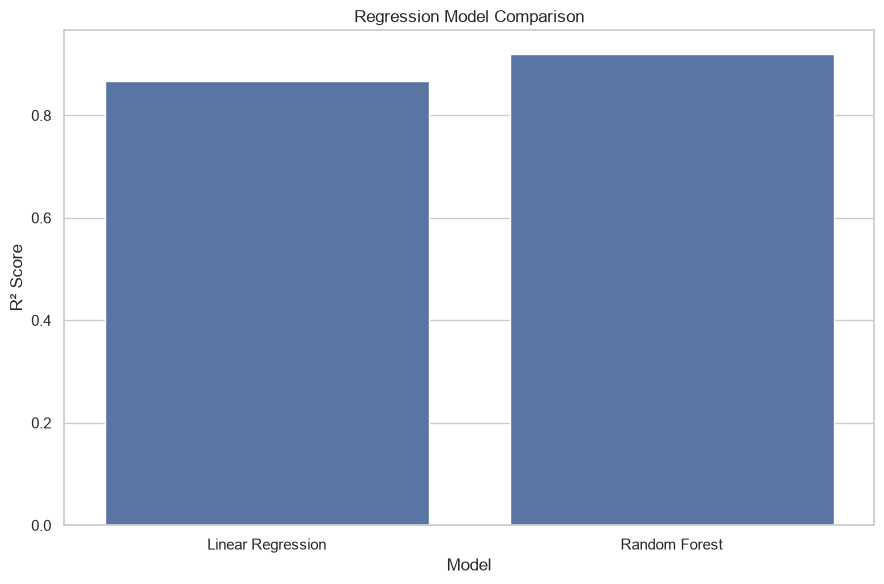

In [48]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="R2 Score"
)

plt.title("Regression Model Comparison")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.tight_layout()
plt.show()

In [49]:
best_model_row = model_comparison.loc[
    model_comparison["R2 Score"].idxmax()
]

print("Best Performing Model:")
print(best_model_row)

Best Performing Model:
Model       Random Forest
MAE          38745.054098
RMSE           85139.2188
R2 Score         0.919611
Name: 1, dtype: object


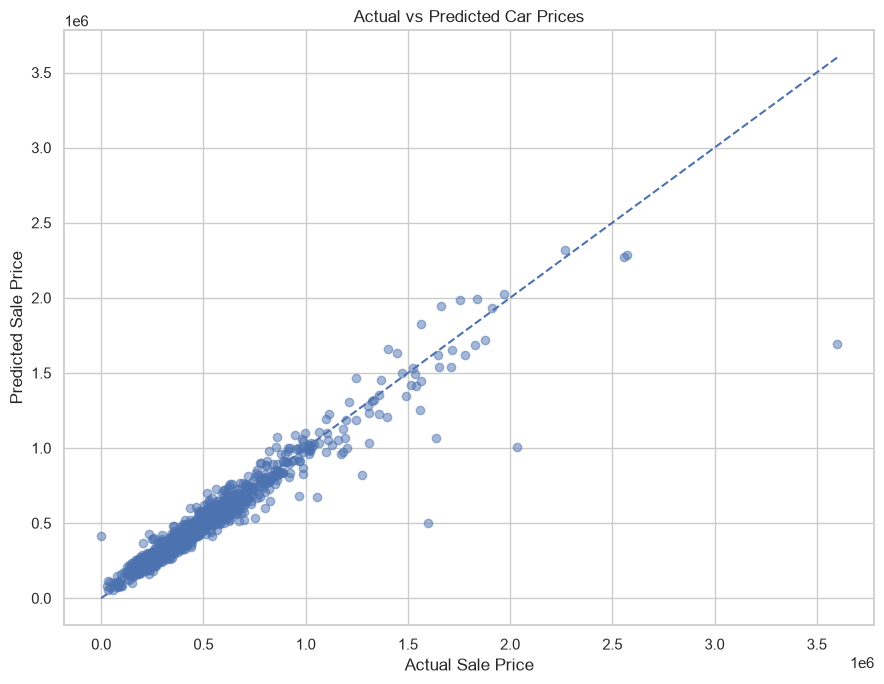

In [50]:
plt.figure(figsize=(9, 7))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.5
)

min_value = min(y_test.min(), y_pred_rf.min())
max_value = max(y_test.max(), y_pred_rf.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Actual vs Predicted Car Prices")
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")

plt.tight_layout()
plt.show()

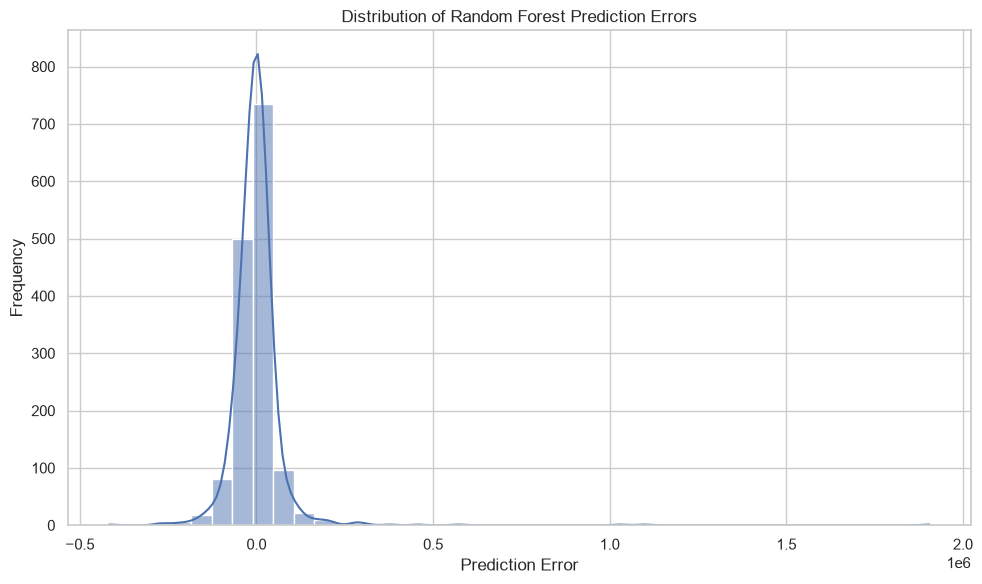

In [51]:
rf_errors = y_test - y_pred_rf

plt.figure(figsize=(10, 6))

sns.histplot(
    rf_errors,
    bins=40,
    kde=True
)

plt.title("Distribution of Random Forest Prediction Errors")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [52]:
sample_car = X_test.iloc[[0]]

predicted_price = random_forest_model.predict(sample_car)[0]
actual_price = y_test.iloc[0]

print("Actual Price    :", round(actual_price, 2))
print("Predicted Price :", round(predicted_price, 2))

Actual Price    : 420000
Predicted Price : 350025.87


In [53]:
preprocessor_fitted = random_forest_model.named_steps["preprocessor"]

rf_model = random_forest_model.named_steps["model"]

feature_names = preprocessor_fitted.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
4,num__original_price,0.556844
1,num__car_age,0.062018
0,num__yr_mfr,0.061499
23,cat__body_type_hatchback,0.039192
24,cat__body_type_luxury sedan,0.032748
25,cat__body_type_luxury suv,0.027506
2,num__kms_run,0.020205
26,cat__body_type_sedan,0.012754
120,cat__model_fortuner,0.009952
144,cat__model_innova crysta,0.009837


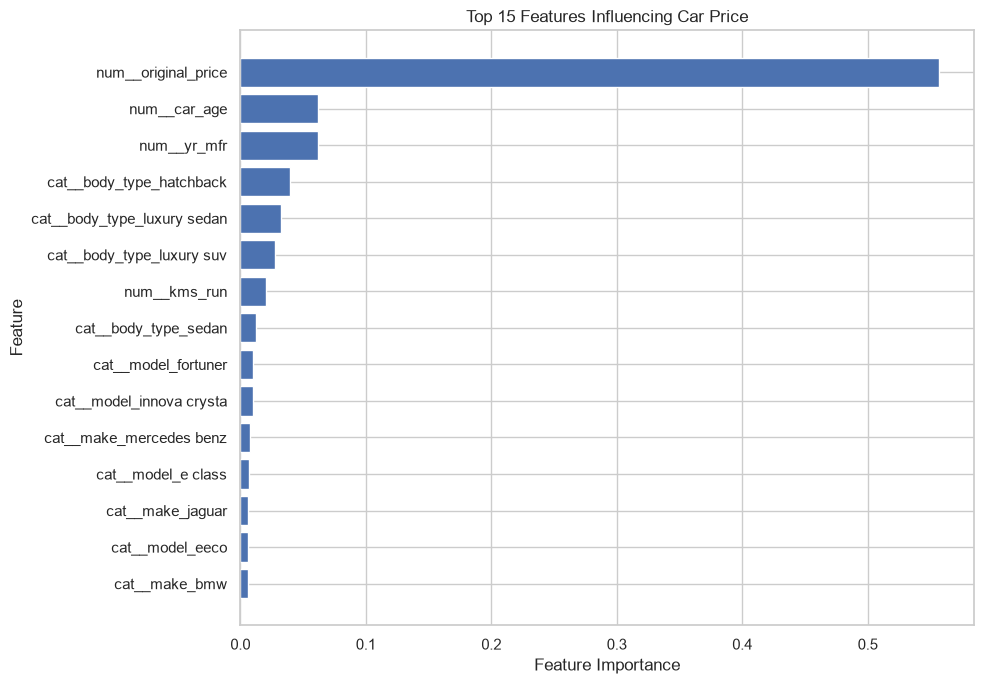

In [54]:
top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Features Influencing Car Price")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [55]:
print("Top 10 Important Features:")

print(
    feature_importance.head(10).to_string(index=False)
)

Top 10 Important Features:
                    Feature  Importance
        num__original_price    0.556844
               num__car_age    0.062018
                num__yr_mfr    0.061499
   cat__body_type_hatchback    0.039192
cat__body_type_luxury sedan    0.032748
  cat__body_type_luxury suv    0.027506
               num__kms_run    0.020205
       cat__body_type_sedan    0.012754
        cat__model_fortuner    0.009952
   cat__model_innova crysta    0.009837


In [56]:
final_results = model_comparison.copy()

final_results["MAE"] = final_results["MAE"].round(2)
final_results["RMSE"] = final_results["RMSE"].round(2)
final_results["R2 Score"] = final_results["R2 Score"].round(4)

final_results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,55361.75,109394.75,0.8673
1,Random Forest,38745.05,85139.22,0.9196


# 8. Conclusion

This project developed a machine learning workflow for predicting used car prices.

The analysis included:

- Data cleaning
- Missing-value analysis
- Duplicate removal
- Exploratory data analysis
- Feature engineering
- Feature selection
- Train-test splitting
- Numerical preprocessing
- Categorical encoding
- Linear Regression
- Random Forest Regression
- MAE, RMSE, and R² evaluation
- Actual versus predicted price analysis
- Prediction-error analysis
- Feature importance analysis

The models were compared using MAE, RMSE, and R².

The final model was selected based on performance on unseen test data, with lower MAE and RMSE and higher R² indicating better predictive performance.

Feature importance analysis was also used to understand which vehicle characteristics contributed most strongly to the Random Forest model's predictions.

# 9. Project Summary

### Problem
Predict the selling price of used cars using machine learning.

### Target Variable
`sale_price`

### Main Features
Vehicle age, kilometres driven, fuel type, city, body type, transmission, make, model, ownership, original price, car rating, and vehicle certification information.

### Models
- Linear Regression
- Random Forest Regression

### Evaluation Metrics
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

### Technologies
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

# 10. Key Findings

### Model Performance

Two regression models were evaluated: Linear Regression and Random Forest Regression.

Random Forest performed better than Linear Regression across all three evaluation metrics.

- Linear Regression R²: **0.8673**
- Random Forest R²: **0.9196**
- Linear Regression MAE: **55,361.75**
- Random Forest MAE: **38,745.05**
- Linear Regression RMSE: **109,394.75**
- Random Forest RMSE: **85,139.22**

The Random Forest model was therefore selected as the best-performing model.

### Feature Importance

The Random Forest feature importance analysis showed that `original_price` was the most influential feature, contributing approximately **55.68%** of the model's total feature importance.

Other important features included:

- `car_age` — 6.20%
- `yr_mfr` — 6.15%
- `body_type_hatchback` — 3.92%
- `body_type_luxury sedan` — 3.27%
- `body_type_luxury suv` — 2.75%
- `kms_run` — 2.02%

This indicates that the original price and vehicle age/manufacturing year were particularly influential in predicting the sale price.

### Prediction Analysis

The actual-versus-predicted visualization showed that most predictions followed the expected relationship between actual and predicted prices. Some larger deviations were visible for higher-priced vehicles, indicating that these cases were more difficult for the model to predict accurately.